# 4、KNN图像识别实战

## 4.1、图像识别【实战案例】

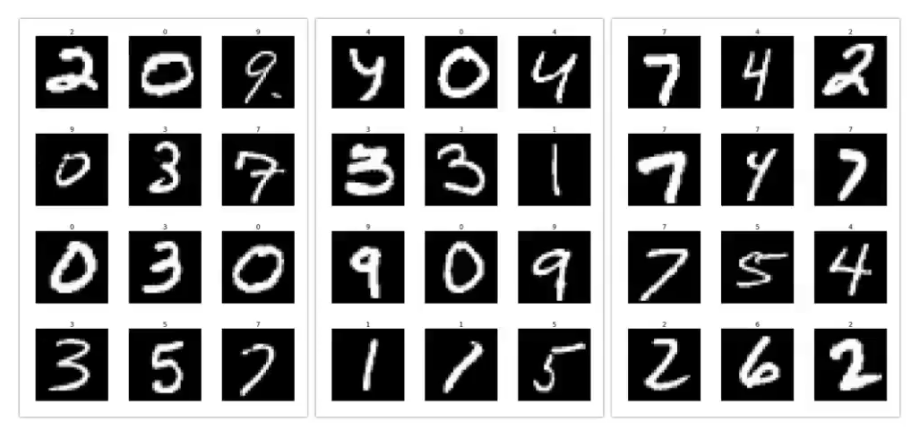

- 数据加载
- 数据介绍
- 目标值构建
- 算法建模
- 算法预测
- 数据可视化

### 4.1.1、加载数据

In [1]:
import numpy as np
data = np.load('./digit.npy')
data

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [2]:
data.shape

(5000, 28, 28)

In [3]:
import matplotlib.pyplot as plt

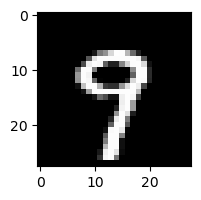

In [4]:
plt.figure(figsize=(2,2))
# 0-9,500个一组，依次是：0、1、2......
plt.imshow(data[4999], cmap='gray')

### 4.1.2、构建目标值

In [5]:
y = list(np.arange(0, 10)) * 500
y.sort()
y = np.array(y)
y

array([0, 0, 0, ..., 9, 9, 9])

### 4.1.3、数据拆分与处理

In [6]:
from sklearn.model_selection import train_test_split

X=data.reshape(5000,-1)

X.shape # 784 像素值，特征

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1024)

display(X_train.shape,y_train.shape)

(4000, 784)

(4000,)

### 4.1.4、建模

In [7]:
from sklearn.neighbors import KNeighborsClassifier

In [8]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.946

### 4.1.5、超参数优化

In [9]:
%%time

from sklearn.model_selection import GridSearchCV

params = dict(n_neighbors = [3,5,10,15,17,23,30],
weights =['uniform',"distance"],
p =[1,2])

estimator =KNeighborsClassifier()

gCV = GridSearchCV(estimator,params,cv=5,scoring='accuracy')

gCV.fit(X_train,y_train)

CPU times: total: 3min
Wall time: 2min 21s


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 10, 15, 17, 23, 30], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [10]:
gCV.best_score_

np.float64(0.93225)

In [11]:
gCV.best_params_

{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}

In [12]:
best_model = gCV.best_estimator_
y_pred = best_model.predict(X_test)

In [13]:
print(y_test[:30])

[0 7 1 7 4 2 1 1 6 5 2 0 9 6 1 6 1 2 8 9 9 6 4 8 0 5 7 6 4 0]


In [14]:
best_model.score(X_test, y_test)

0.949

### 4.1.6、可视化

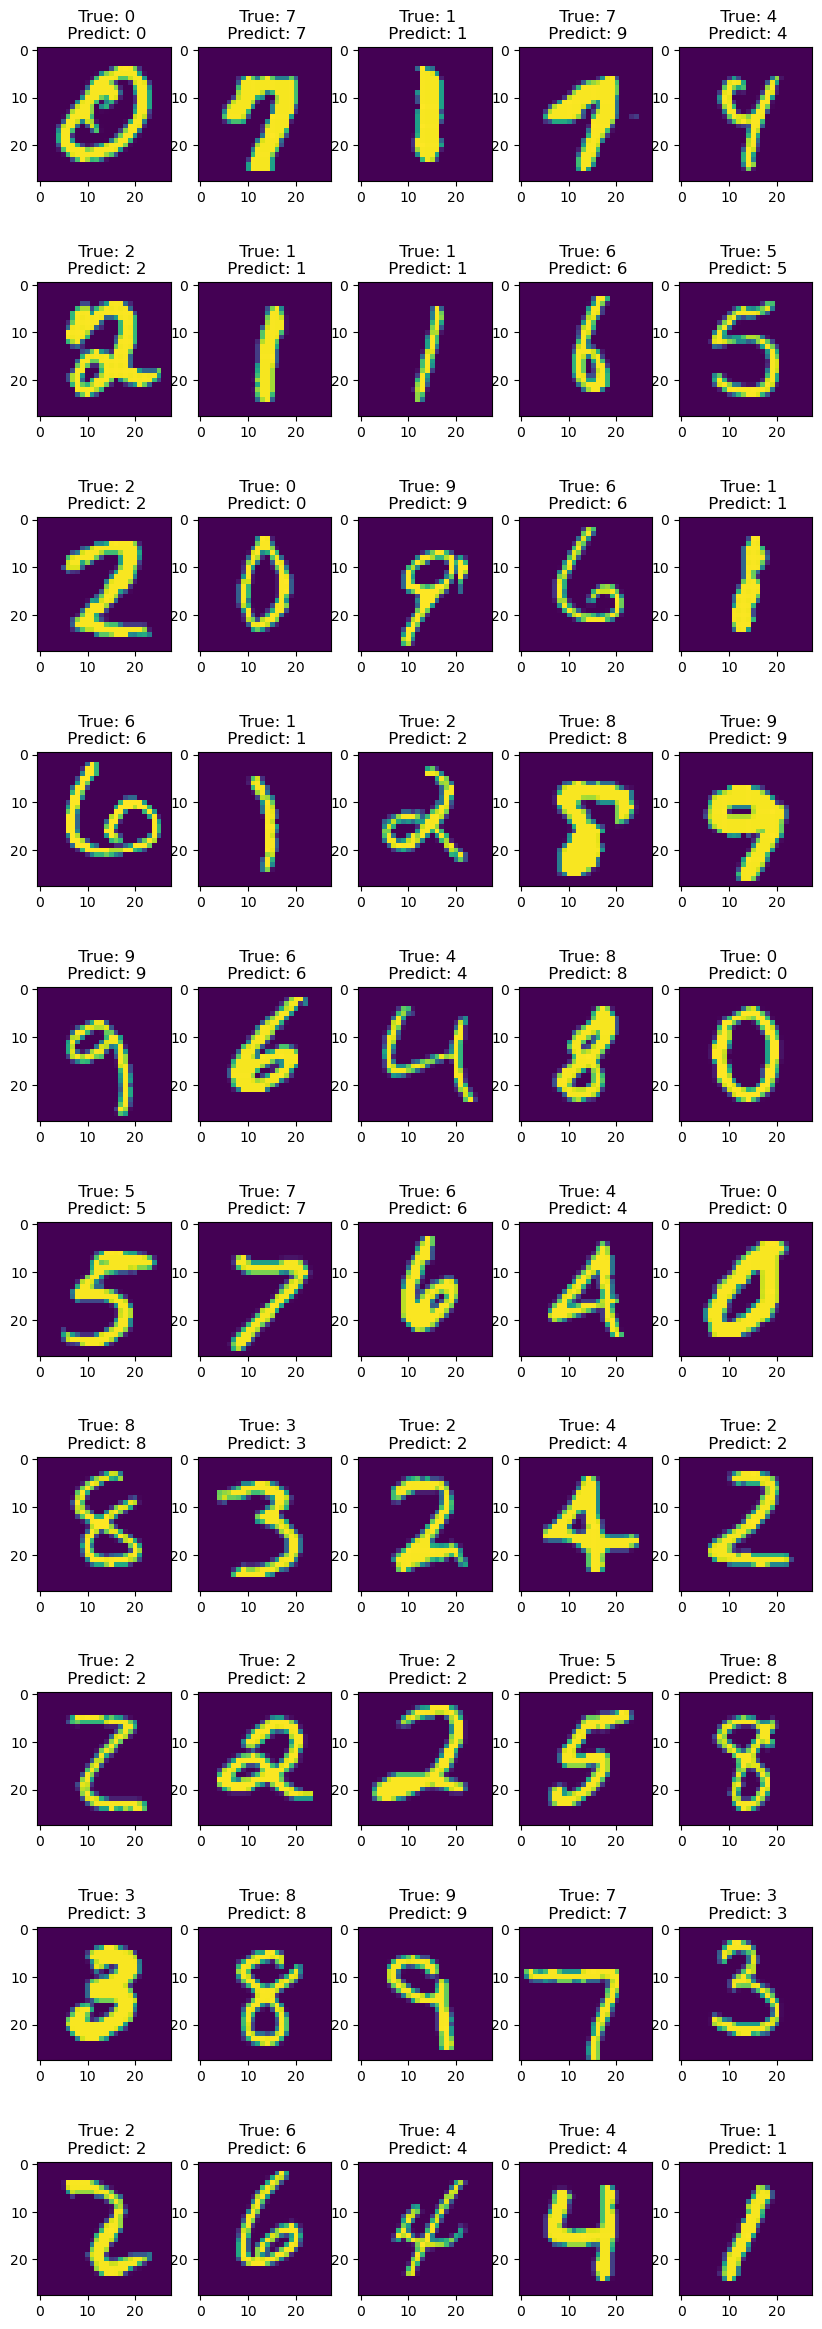

In [15]:
plt.figure(figsize=(5 *2,10 * 3))

for i in range(50):
    plt.subplot(10,5,i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    true = y_test[i]
    pred = y_pred[i]
    plt. title(f' True: {true}\n Predict: {pred}')